### Retiro Fugas

In [1]:

import sys 
sys.path.append('C:/Users/Data/Documents/lazo_fernando/target_script_01/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *
from sqlalchemy import create_engine
from sqlalchemy import text

fecha_mes_base='2026-09-01'

filename='retiro_tc_04.xlsx'
name_dni='DNI'

ruta_archivo = os.path.join(ruta_diners_tc, filename)
df = pd.read_excel(ruta_archivo)

df[f"{name_dni}"] = (
    df[f"{name_dni}"]
    .astype(str)
    .str.zfill(8)
)

df = df.rename(columns={
    f'{name_dni}': 'NUMERO_DOCUMENTO'
})
df=df[["NUMERO_DOCUMENTO"]]
df.head()
server_sql = server_kishin
db_sql = "DANTALION"
user_sql = user_kishin
pwd_sql = pwd_kishin

engine_kishin = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
query = f"""
	select NUMERO_DOCUMENTO
	from DANTALION.dbo.Base_Maestra_Diners_TC_Vigente
"""
df_tc = pd.read_sql(query, engine_kishin)


In [2]:
df_tc.shape

(29792, 1)

In [3]:
df.shape

(860, 1)

In [ ]:
campana='dinersTc'
query = f"""
    select FECHA as fecha_gestion,DNI as NUMERO_DOCUMENTO,
    PROMOTOR as promotor,
    ESTADO as estado_venta,
    TRAMA_HORA as tramo_venta,
    MONTO as monto_venta,
    DNIEjecutivo as dni_ejecutivo_venta,
    Producto as producto_venta,
    Producto as title,
    Celular as cel_venta,1 as venta,
    subcampana
    from SAMANTHA.dbo.Ventas_Target
    where campana='{campana}'
    and cast(fecha as date) between '{fecha_mes_base}' and EOMONTH('{fecha_mes_base}')
"""
df_ventas = pd.read_sql(query, engine_samantha)
df = df[
    ~df["NUMERO_DOCUMENTO"].isin(df_ventas["NUMERO_DOCUMENTO"])
].copy()
df_ventas.shape[0]



In [5]:
df.merge(df_tc, on='NUMERO_DOCUMENTO', how='inner').count()


NUMERO_DOCUMENTO    18
dtype: int64

In [2]:
df=df.merge(df_tc, on='NUMERO_DOCUMENTO', how='inner')

In [3]:

list_dni = (
    df['NUMERO_DOCUMENTO']
    .dropna()
    .drop_duplicates()
    .tolist()
)
in_clause = ",".join(f"'{x}'" for x in list_dni)

in_clause

"'73568906','43659243','46389180','73073273','42844101','42784866','46038626','72649370','40227906','73345656','42725095','45853146','74090141','45811914','72943026','74084466','29654839','45465240','46565800','72470910','48395987','45723244','40858792','48115470','73644105'"

In [4]:
fecha_mes_base

'2026-09-01'

In [5]:
try:
    with engine_kishin.begin() as conn:
        query = f"""
            UPDATE DANTALION.dbo.Base_Maestra_Diners_TC
            SET RETIRO = 'RETIRO_04'
            WHERE NUMERO_DOCUMENTO IN ({in_clause})
                and fecha_envio >= '{fecha_mes_base}'
                AND fecha_envio <= EOMONTH('{fecha_mes_base}')
                and RETIRO is null 
        """
        result = conn.execute(text(query))
        print("Filas actualizadas:", result.rowcount)

except Exception as e:
    print(e)

Filas actualizadas: 7


In [6]:
server_sql = server_zeus
db_sql = "ODIN"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_odin = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)

In [8]:
try:
    with engine_odin.begin() as conn:
        query = f"""
            UPDATE odin.dbo.Base_Maestra_Diners_TC_vigente
            SET RETIRO = 'RETIRO_04'
            WHERE NUMERO_DOCUMENTO IN ({in_clause})
        """
        result = conn.execute(text(query))
        print("Filas actualizadas:", result.rowcount)

except Exception as e:
    print(e)

Filas actualizadas: 25


In [9]:
try:
    with engine_kishin.begin() as conn:
        query = f"""
            UPDATE DANTALION.dbo.Base_Maestra_Diners_TC
            SET RETIRO = 'RETIRO_20'
            WHERE NUMERO_DOCUMENTO IN ({in_clause})
                and fecha_envio >= '{fecha_mes_base}'
                AND fecha_envio <= EOMONTH('{fecha_mes_base}')
                and RETIRO is null 
        """
        result = conn.execute(text(query))
        print("Filas actualizadas:", result.rowcount)

except Exception as e:
    print(e)

Filas actualizadas: 924


In [20]:
print(1547+924+53)

2524


In [10]:
fecha_mes_base

'2026-08-01'

In [ ]:

df_ventas.head()

,fecha_gestion,NUMERO_DOCUMENTO,promotor,estado_venta,tramo_venta,monto_venta,dni_ejecutivo_venta,producto_venta,title,cel_venta,venta,subcampana
0,2026-07-01,07259135,08728081,1.-VALIDADA,9,None,08728081,None,None,981260227,1,None
1,2026-07-01,07779510,44592143,6.-SIN VALIDAR,13,None,44592143,None,None,989371280,1,None
2,2026-07-01,40102384,44592143,1.-VALIDADA,10,None,44592143,None,None,932595948,1,None
3,2026-07-01,40552162,47202133,1.-VALIDADA,10,None,47202133,None,None,988594366,1,None
4,2026-07-01,41266190,44592143,1.-VALIDADA,9,None,44592143,None,None,940049145,1,None


In [2]:
exec_query_sql(server_kishin, db_kishin, user_kishin, pwd_kishin, "tNumeros_Diners_tc", "SP tNumeros diners TC")
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC Sp_Actualizar_Diners_tc", "SP actualizar diners TC Zeus")
exec_query_sql(server_sa, "ODIN", user_sa, pwd_sa, "EXEC Sp_Actualizar_Diners_tc", "SP actualizar diners TC SA")

SP tNumeros diners TC | realizado | duración: 29.7 seg
SP actualizar diners TC Zeus | realizado | duración: 15.58 seg
SP actualizar diners TC SA | realizado | duración: 2.87 seg


In [ ]:
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC [Cronox].[spGeneradorDinersTarjetas]", "SP actualizar diners TC Zeus")


## Retiros

In [120]:
server_sql = server_zeus
db_sql = "MAEBA"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_maeba = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
query = f"""
	select NUMERO_DOCUMENTO,CNTVTAS as ventas
	from MAEBA.ADM_OBJ_TG.tGestionMesDinersTc
"""
df_funnel = pd.read_sql(query, engine_maeba)
df_funnel = df_funnel.drop_duplicates(
    subset=["NUMERO_DOCUMENTO"]
)

In [121]:
query = f"""
	select *
	from DANTALION.dbo.Base_Maestra_Diners_TC_Vigente
"""
df_tc = pd.read_sql(query, engine_kishin)

In [122]:
df_tc1=df_tc.merge(df_funnel,on='NUMERO_DOCUMENTO',how='left')

In [123]:
columnas_bench = [
    'L_IBK', 'L_BCP', 'L_BBVA', 'L_SCO',
    'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP',
    'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT',
    'L_UNO', 'L_GNB', 'L_EFE', 'L_COM',
    'L_NAC'

]

# Mayor monto entre todas las columnas
df_tc1["monto_bench"] = df_tc1[columnas_bench].max(axis=1)

# Identificar qué columna tiene el mayor monto
df_tc1["bench"] = df_tc1[columnas_bench].idxmax(axis=1)

# Bancos que queremos identificar individualmente
bancos_principales = [
    "l_ibk",
    "l_bcp",
    "l_bbva",
    "l_sco"
]

# Si el ganador NO pertenece a esos bancos → OTROS
df_tc1.loc[
    ~df_tc1["bench"].isin(bancos_principales),
    "bench"
] = "OTROS"

# Si todas las columnas son NaN
mask = df_tc1[columnas_bench].isna().all(axis=1)

df_tc1.loc[mask, "bench"] = "OTROS"

df_tc1["RETIRO"] = df_tc1["RETIRO"].replace({
    "RETIRO_27_correo": "RETIRO_17"
})

df_tc1["dia_retiro"] = (
    df_tc1["RETIRO"]
    .str.extract(r"RETIRO_(\d+)", expand=False)
    .astype("Int64")
)
df_tc1["estado_base"] = df_tc1["RETIRO"].isna().map({
    True: "VIGENTE",
    False: "RETIRADO"
})



In [124]:
import numpy as np
df_tc1["LINEA CREDITO DOLARES"] = pd.to_numeric(
    df_tc1["LINEA CREDITO DOLARES"],
    errors="coerce"
)
df_tc1["rango_linea"] = pd.cut(
    df_tc1["LINEA CREDITO DOLARES"],
    bins=[-np.inf, 2000, 4000, 6000, 8000, 10000, 12000, np.inf],
    labels=["1K - 2K", "2K - 4K", "4K - 6K", "6K - 8K", "8K - 10K",  "10K - 12K", "> 12K"]
)


df_tc1["rango_linea"] = (
    df_tc1["rango_linea"]
    .cat.add_categories("SIN LINEA")
    .fillna("SIN LINEA")
)

In [125]:

df_tc1["FECHA_ENVIO"] = pd.to_datetime(
    df_tc1["FECHA_ENVIO"],
    errors="coerce"
)

In [127]:
df_resumen_funnel = df_tc1.copy()

# ============================================================
# 1. LIMPIAR DNI
# ============================================================

df_resumen_funnel["NUMERO_DOCUMENTO"] = (
    df_resumen_funnel["NUMERO_DOCUMENTO"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
    .str.zfill(8)
)

# ============================================================
# 2. FECHA DE ENVÍO
# ============================================================

df_resumen_funnel["FECHA_ENVIO"] = pd.to_datetime(
    df_resumen_funnel["FECHA_ENVIO"],
    errors="coerce"
)

# ============================================================
# 3. UNA FILA POR CLIENTE
# Si existen duplicados, nos quedamos con el último envío
# ============================================================

df_resumen_funnel = (
    df_resumen_funnel
    .sort_values("FECHA_ENVIO")
    .drop_duplicates(
        subset=["NUMERO_DOCUMENTO"],
        keep="last"
    )
    .copy()
)

print(df_resumen_funnel.shape)
print(df_resumen_funnel["NUMERO_DOCUMENTO"].nunique())

(35333, 145)
35333


In [129]:
print(df_resumen_funnel.columns.tolist())

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'CELULAR7', 'CELULAR8', 'CELULAR9', 'CELULAR10', 'PERFIL', 'PRODUCTO', 'LINEA CREDITO DOLARES', 'ID RESULTADO GESTION', 'TCEA', 'TCEA_CUOTAS_DF', 'LIMAPROVINCIA', 'GRUPO_EJECUCION', 'FEC_NAC', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'RECURRENCIA', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'CEL09', 'CEL10', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETI

In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'CELULAR7', 'CELULAR8', 'CELULAR9', 'CELULAR10', 'PERFIL', 'PRODUCTO', 'LINEA CREDITO DOLARES', 'ID RESULTADO GESTION', 'TCEA', 'TCEA_CUOTAS_DF', 'LIMAPROVINCIA', 'GRUPO_EJECUCION', 'FEC_NAC', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'RECURRENCIA', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'CEL09', 'CEL10', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETIRO', 'MARCA', 'MARCA2', 'FLAT1', 'FLAT2', 'FLAT3', 'REP1', 'REP2', 'TASA_ANT', 'TCEA_ANT', 'FLG_BT', 'MONTO_OFERTA_BT', 'PRIORIDAD_TELEFONO_1', 'PRIORIDAD_TELEFONO_2', 'PRIORIDAD_TELEFONO_3', 'PRIORIDAD_TELEFONO_4', 'PRIORIDAD_TELEFONO_5', 'NEW_PROFILE', 'CPRUEBA', 'REP3', 'LAST_ENVIO', 'TASATEAA', 'TEA_DFA', 'TCEAA', 'TCEA_CUOTAS_DFA', 'MARCA3', 'PROP202407', 'PROP202407_el1ro5j', 'CAMPANASYD', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'PROB_CONTACTO', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CASHBACK', 'CONTEO', 'leadslanding', 'PROSPECTO_NUEVO', 'PROD_NOVIEMBRE', 'MEJ_PROD', 'LC', 'FLG_20241206', 'MAYOR_LINEA', 'MILLAS', 'prioridadtasas', 'prioridadedad', 'FRESCURA_TARGET', 'SEGMENTO_LABORAL', 'N_BASE', 'MARCA_SPEECH', 'BENCH_DINERS', 'FEC_ENV', 'ventas', 'monto_bench', 'bench', 'dia_retiro', 'estado_base', 'rango_linea', 'EN_BASE']
venta

In [128]:
df_resumen_funnel["EN_BASE"] = 1
total_base = df_resumen_funnel["NUMERO_DOCUMENTO"].nunique()

print("Clientes en base:", total_base)

Clientes en base: 35333


In [130]:
columnas_funnel = [
    "NUMERO_DOCUMENTO",
    "FECHA_ENVIO",
    "PERFIL",
    "PROB_CONTACTO",
    "LIMAPROVINCIA",
    "SEGMENTO_LABORAL",
    "RECURRENCIA",
    "N_BASE",
    "estado_base",
    "rango_linea",
    'ventas'
]

df_resumen_funnel = df_resumen_funnel[
    [c for c in columnas_funnel if c in df_resumen_funnel.columns]
].copy()

In [131]:
# ============================================================
# DISTRIBUCIÓN POR PRIORIDAD
# ============================================================

dist_prioridad = (
    df_resumen_funnel
    .groupby("PROB_CONTACTO", dropna=False)
    .agg(
        clientes=("NUMERO_DOCUMENTO", "nunique")
    )
    .reset_index()
)

dist_prioridad["porcentaje"] = (
    dist_prioridad["clientes"]
    / dist_prioridad["clientes"].sum()
    * 100
)

display(dist_prioridad)
# ============================================================
# DISTRIBUCIÓN POR RANGO DE LÍNEA
# ============================================================

dist_rango = (
    df_resumen_funnel
    .groupby("rango_linea", dropna=False)
    .agg(
        clientes=("NUMERO_DOCUMENTO", "nunique")
    )
    .reset_index()
)

dist_rango["porcentaje"] = (
    dist_rango["clientes"]
    / dist_rango["clientes"].sum()
    * 100
)

dist_rango = dist_rango.sort_values(
    "clientes",
    ascending=False
)

display(dist_rango)

,PROB_CONTACTO,clientes,porcentaje
0,A,566,1.601902
1,B,1151,3.257578
2,C,2546,7.205728
3,D,3607,10.208587
4,E,2791,7.899131
5,F,8089,22.893612
6,G,9054,25.624770
7,H,5430,15.368070
8,I,2099,5.940622


C:\Users\DATA\AppData\Local\Temp\ipykernel_4184\2902111662.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rango_linea", dropna=False)


,rango_linea,clientes,porcentaje
1,2K - 4K,13557,38.369230
0,1K - 2K,8579,24.280418
2,4K - 6K,7664,21.690771
4,8K - 10K,2095,5.929301
3,6K - 8K,1882,5.326465
5,10K - 12K,927,2.623610
6,> 12K,629,1.780205
7,SIN LINEA,0,0.000000


In [133]:
print(df_resumen_funnel.columns.tolist())

['NUMERO_DOCUMENTO', 'FECHA_ENVIO', 'PERFIL', 'PROB_CONTACTO', 'LIMAPROVINCIA', 'SEGMENTO_LABORAL', 'RECURRENCIA', 'N_BASE', 'estado_base', 'rango_linea', 'ventas']


In [134]:
resumen_rango = (
    df_resumen_funnel
    .groupby("rango_linea", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_rango["pct_venta"] = (
    resumen_rango["ventas"]
    / resumen_rango["base"]
    * 100
)

resumen_rango = resumen_rango.sort_values(
    "pct_venta",
    ascending=False
)

resumen_rango

C:\Users\DATA\AppData\Local\Temp\ipykernel_4184\678519115.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rango_linea", dropna=False)


,rango_linea,base,ventas,pct_venta
3,6K - 8K,1882,19.0,1.009564
2,4K - 6K,7664,42.0,0.548017
4,8K - 10K,2095,11.0,0.525060
0,1K - 2K,8579,44.0,0.512880
6,> 12K,629,3.0,0.476948
1,2K - 4K,13557,61.0,0.449952
5,10K - 12K,927,4.0,0.431499
7,SIN LINEA,0,0.0,NaN


In [136]:
resumen_prioridad = (
    df_resumen_funnel
    .groupby("PROB_CONTACTO", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_prioridad["pct_venta"] = (
    resumen_prioridad["ventas"]
    / resumen_prioridad["base"]
    * 100
)

resumen_prioridad = resumen_prioridad.sort_values(
    "pct_venta",
    ascending=False
)

resumen_prioridad

,PROB_CONTACTO,base,ventas,pct_venta
0,A,566,32.0,5.653710
1,B,1151,49.0,4.257168
2,C,2546,54.0,2.120974
3,D,3607,22.0,0.609925
4,E,2791,9.0,0.322465
5,F,8089,12.0,0.148350
8,I,2099,2.0,0.095283
7,H,5430,3.0,0.055249
6,G,9054,1.0,0.011045


In [137]:
prioridades_abcd = ["A", "B", "C", "D"]

df_abcd = df_resumen_funnel[
    df_resumen_funnel["PROB_CONTACTO"].isin(prioridades_abcd)
].copy()

In [139]:
resumen_prioridad_rango = (
    df_resumen_funnel
    .groupby(
        ["PROB_CONTACTO", "rango_linea"],
        dropna=False
    )
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_prioridad_rango["pct_ventas"] = (
    resumen_prioridad_rango["ventas"]
    / resumen_prioridad_rango["base"]
    * 100
)

resumen_prioridad_rango = (
    resumen_prioridad_rango
    .sort_values(
        ["PROB_CONTACTO", "pct_ventas"],
        ascending=[True, False]
    )
)

resumen_prioridad_rango

C:\Users\DATA\AppData\Local\Temp\ipykernel_4184\3801196732.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(


,PROB_CONTACTO,rango_linea,base,ventas,pct_ventas
4,A,8K - 10K,47,5.0,10.638298
3,A,6K - 8K,43,4.0,9.302326
6,A,> 12K,22,2.0,9.090909
5,A,10K - 12K,16,1.0,6.250000
1,A,2K - 4K,203,11.0,5.418719
...,...,...,...,...,...
67,I,6K - 8K,95,0.0,0.000000
68,I,8K - 10K,54,0.0,0.000000
69,I,10K - 12K,28,0.0,0.000000
70,I,> 12K,14,0.0,0.000000


In [140]:
prioridades = ["A", "B", "C", "D"]

analisis_abcd = (
    resumen_prioridad_rango[
        resumen_prioridad_rango["PROB_CONTACTO"].isin(prioridades)
    ]
    .copy()
)

In [141]:
matriz_pct = (
    analisis_abcd
    .pivot(
        index="rango_linea",
        columns="PROB_CONTACTO",
        values="pct_ventas"
    )
    .reindex(columns=["A", "B", "C", "D"])
)

matriz_pct.round(2)

PROB_CONTACTO,A,B,C,D
rango_linea,,,,
1K - 2K,5.41,3.52,2.12,1.37
2K - 4K,5.42,3.80,1.79,0.26
4K - 6K,3.11,6.01,1.65,0.81
6K - 8K,9.30,7.79,4.32,0.00
8K - 10K,10.64,3.95,2.19,0.00
10K - 12K,6.25,0.00,5.77,0.00
> 12K,9.09,0.00,4.35,0.00
SIN LINEA,NaN,NaN,NaN,NaN


In [142]:
matriz_base = (
    analisis_abcd
    .pivot(
        index="rango_linea",
        columns="PROB_CONTACTO",
        values="base"
    )
    .reindex(columns=["A", "B", "C", "D"])
)

matriz_base

PROB_CONTACTO,A,B,C,D
rango_linea,,,,
1K - 2K,74,199,567,874
2K - 4K,203,500,1061,1518
4K - 6K,161,233,544,743
6K - 8K,43,77,162,183
8K - 10K,47,76,137,183
10K - 12K,16,40,52,60
> 12K,22,26,23,46
SIN LINEA,0,0,0,0


In [144]:
resumen_rango_abc = (
    df_resumen_funnel[
        df_resumen_funnel["PROB_CONTACTO"].isin(["A", "B", "C"])
    ]
    .groupby("rango_linea", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_rango_abc["pct_venta"] = (
    resumen_rango_abc["ventas"]
    / resumen_rango_abc["base"]
    * 100
)

resumen_rango_abc = resumen_rango_abc.sort_values(
    "pct_venta",
    ascending=False
)

resumen_rango_abc

C:\Users\DATA\AppData\Local\Temp\ipykernel_4184\977761489.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rango_linea", dropna=False)


,rango_linea,base,ventas,pct_venta
3,6K - 8K,282,17.0,6.028369
4,8K - 10K,260,11.0,4.230769
6,> 12K,71,3.0,4.225352
5,10K - 12K,108,4.0,3.703704
2,4K - 6K,938,28.0,2.985075
1,2K - 4K,1764,49.0,2.777778
0,1K - 2K,840,23.0,2.738095
7,SIN LINEA,0,0.0,NaN


In [145]:
resumen_perfil = (
    df_resumen_funnel
    .groupby("PERFIL", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_perfil["pct_venta"] = (
    resumen_perfil["ventas"]
    / resumen_perfil["base"]
    * 100
)

resumen_perfil = resumen_perfil.sort_values(
    "pct_venta",
    ascending=False
)

resumen_perfil

,PERFIL,base,ventas,pct_venta
0,PERFIL DM,13726,73.0,0.531837
1,PERFIL SE,21607,111.0,0.513722


In [ ]:
resumen_recencia_abc = (
    df_resumen_funnel[
        df_resumen_funnel["PROB_CONTACTO"].isin(["A", "B", "C"])
    ]
    .groupby("RECURRENCIA", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_recencia_abc["pct_venta"] = (
    resumen_recencia_abc["ventas"]
    / resumen_recencia_abc["base"]
    * 100
)

resumen_recencia_abc.sort_values(
    "pct_venta",
    ascending=False
)

,RECURRENCIA,base,ventas,pct_venta
0,NUEVO,1894,109.0,5.755016
1,STOCK,2369,26.0,1.097509


In [149]:
resumen_lima_prov_abc = (
    df_resumen_funnel[
        df_resumen_funnel["PROB_CONTACTO"].isin(["A", "B", "C"])
    ]
    .groupby("LIMAPROVINCIA", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_lima_prov_abc["pct_venta"] = (
    resumen_lima_prov_abc["ventas"]
    / resumen_lima_prov_abc["base"]
    * 100
)

resumen_lima_prov_abc.sort_values(
    "pct_venta",
    ascending=False
)

,LIMAPROVINCIA,base,ventas,pct_venta
0,LIMA,2860,93.0,3.251748
1,PROVINCIA,1403,42.0,2.993585


In [151]:
resumen_prioridad_recurrencia = (
    df_resumen_funnel[
        df_resumen_funnel["PROB_CONTACTO"].isin(["A", "B", "C"])
    ]
    .groupby(
        ["PROB_CONTACTO", "RECURRENCIA"],
        dropna=False
    )
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_prioridad_recurrencia["pct_venta"] = (
    resumen_prioridad_recurrencia["ventas"]
    / resumen_prioridad_recurrencia["base"]
    * 100
)

resumen_prioridad_recurrencia.sort_values(
    ["PROB_CONTACTO", "pct_venta"],
    ascending=[True, False]
)

,PROB_CONTACTO,RECURRENCIA,base,ventas,pct_venta
0,A,NUEVO,566,32.0,5.653710
1,B,NUEVO,906,46.0,5.077263
2,B,STOCK,245,3.0,1.224490
3,C,NUEVO,422,31.0,7.345972
4,C,STOCK,2124,23.0,1.082863


In [153]:
resumen_nuevo_abc_rango = (
    df_resumen_funnel[
        (df_resumen_funnel["RECURRENCIA"] == "NUEVO") &
        (df_resumen_funnel["PROB_CONTACTO"].isin(["A", "B", "C"]))
    ]
    .groupby("rango_linea", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_nuevo_abc_rango["pct_venta"] = (
    resumen_nuevo_abc_rango["ventas"]
    / resumen_nuevo_abc_rango["base"]
    * 100
)

resumen_nuevo_abc_rango.sort_values(
    "pct_venta",
    ascending=False
)

C:\Users\DATA\AppData\Local\Temp\ipykernel_4184\891296121.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rango_linea", dropna=False)


,rango_linea,base,ventas,pct_venta
3,6K - 8K,131,15.0,11.450382
5,10K - 12K,63,4.0,6.349206
4,8K - 10K,147,9.0,6.122449
6,> 12K,51,3.0,5.882353
0,1K - 2K,308,18.0,5.844156
2,4K - 6K,432,24.0,5.555556
1,2K - 4K,762,36.0,4.724409
7,SIN LINEA,0,0.0,NaN


In [155]:
# ============================================================
# EMBUDO DE RETIROS
# ============================================================

total_base = df_resumen_funnel["NUMERO_DOCUMENTO"].nunique()
total_ventas = df_resumen_funnel["ventas"].sum()

# NIVEL 1: BASE TOTAL
nivel_1 = df_resumen_funnel.copy()

# NIVEL 2: NUEVOS
nivel_2 = df_resumen_funnel[
    df_resumen_funnel["RECURRENCIA"] == "NUEVO"
].copy()

# NIVEL 3: NUEVOS + ABC
nivel_3 = df_resumen_funnel[
    (df_resumen_funnel["RECURRENCIA"] == "NUEVO") &
    (df_resumen_funnel["PROB_CONTACTO"].isin(["A", "B", "C"]))
].copy()

In [163]:
def calcular_nivel(nombre, df_nivel, total_base, total_ventas):

    clientes = df_nivel["NUMERO_DOCUMENTO"].nunique()
    ventas = df_nivel["ventas"].sum()

    return {
        "nivel": nombre,
        "clientes": clientes,

        "pct_base": (
            clientes / total_base * 100
            if total_base > 0 else 0
        ),

        "ventas": ventas,

        "pct_ventas_capturadas": (
            ventas / total_ventas * 100
            if total_ventas > 0 else 0
        ),

        "tasa_venta": (
            ventas / clientes * 100
            if clientes > 0 else 0
        )
    }

In [164]:
embudo = pd.DataFrame([
    
    calcular_nivel(
        "BASE TOTAL",
        nivel_1,
        total_base,
        total_ventas
    ),

    calcular_nivel(
        "NUEVO",
        nivel_2,
        total_base,
        total_ventas
    ),

    calcular_nivel(
        "NUEVO + ABC",
        nivel_3,
        total_base,
        total_ventas
    )
])

embudo

,nivel,clientes,pct_base,ventas,pct_ventas_capturadas,tasa_venta
0,BASE TOTAL,35333,100.000000,184.0,100.000000,0.520760
1,NUEVO,3858,10.918971,134.0,72.826087,3.473302
2,NUEVO + ABC,1894,5.360428,109.0,59.239130,5.755016


In [165]:
# ============================================================
# NIVEL 4 - ESCENARIOS DE RANGO_LINEA
# ============================================================

# Solo 6K - 8K
nivel_4_a = nivel_3[
    nivel_3["rango_linea"] == "6K - 8K"
].copy()

# 6K - 10K
nivel_4_b = nivel_3[
    nivel_3["rango_linea"].isin([
        "6K - 8K",
        "8K - 10K"
    ])
].copy()

# 6K en adelante
nivel_4_c = nivel_3[
    nivel_3["rango_linea"].isin([
        "6K - 8K",
        "8K - 10K",
        "10K - 12K",
        "> 12K"
    ])
].copy()

In [166]:
comparacion_rangos = pd.DataFrame([
    calcular_nivel(
        "NUEVO + ABC + 6K-8K",
        nivel_4_a,
        total_base,
        total_ventas
    ),

    calcular_nivel(
        "NUEVO + ABC + 6K-10K",
        nivel_4_b,
        total_base,
        total_ventas
    ),

    calcular_nivel(
        "NUEVO + ABC + >=6K",
        nivel_4_c,
        total_base,
        total_ventas
    )
])

comparacion_rangos.round(2)

,nivel,clientes,pct_base,ventas,pct_ventas_capturadas,tasa_venta
0,NUEVO + ABC + 6K-8K,131,0.37,15.0,8.15,11.45
1,NUEVO + ABC + 6K-10K,278,0.79,24.0,13.04,8.63
2,NUEVO + ABC + >=6K,392,1.11,31.0,16.85,7.91


In [167]:
df_resumen_funnel["N_BASE"].value_counts(dropna=False)

N_BASE
Alpha    18390
Sigma     6467
Beta      4542
Gamma     3815
Pi        1271
Iota       458
Zeta       332
kappa       58
Name: count, dtype: int64

In [168]:
df_resumen_funnel["estado_base"].value_counts(dropna=False)

estado_base
VIGENTE     32529
RETIRADO     2804
Name: count, dtype: int64

In [169]:
resumen_n_base = (
    df_resumen_funnel
    .groupby("N_BASE", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_n_base["pct_venta"] = (
    resumen_n_base["ventas"]
    / resumen_n_base["base"]
    * 100
)

resumen_n_base = resumen_n_base.sort_values(
    "pct_venta",
    ascending=False
)

resumen_n_base

,N_BASE,base,ventas,pct_venta
7,kappa,58,3.0,5.172414
4,Pi,1271,38.0,2.989772
3,Iota,458,5.0,1.091703
5,Sigma,6467,68.0,1.051492
2,Gamma,3815,20.0,0.524246
1,Beta,4542,14.0,0.308234
6,Zeta,332,1.0,0.301205
0,Alpha,18390,35.0,0.190321


In [170]:
resumen_estado = (
    df_resumen_funnel
    .groupby("estado_base", dropna=False)
    .agg(
        base=("NUMERO_DOCUMENTO", "nunique"),
        ventas=("ventas", "sum")
    )
    .reset_index()
)

resumen_estado["pct_venta"] = (
    resumen_estado["ventas"]
    / resumen_estado["base"]
    * 100
)

resumen_estado = resumen_estado.sort_values(
    "pct_venta",
    ascending=False
)

resumen_estado

,estado_base,base,ventas,pct_venta
0,RETIRADO,2804,21.0,0.748930
1,VIGENTE,32529,163.0,0.501091


In [92]:
print(df_tc.columns.tolist())

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'CELULAR7', 'CELULAR8', 'CELULAR9', 'CELULAR10', 'PERFIL', 'PRODUCTO', 'LINEA CREDITO DOLARES', 'ID RESULTADO GESTION', 'TCEA', 'TCEA_CUOTAS_DF', 'LIMAPROVINCIA', 'GRUPO_EJECUCION', 'FEC_NAC', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'RECURRENCIA', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'CEL09', 'CEL10', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETI

In [ ]:
analisis_prob = pd.crosstab(
    df_tc["PROB_CONTACTO"],
    df_tc["estado_base"],
    margins=True
)

analisis_prob

estado_base,RETIRADO,VIGENTE,All
PROB_CONTACTO,,,
A,25,541,566
B,55,1096,1151
C,256,2290,2546
D,298,3309,3607
E,470,2321,2791
F,550,7539,8089
G,516,8538,9054
H,383,5047,5430
I,251,1848,2099


In [42]:
analisis_prob_pct = pd.crosstab(
    df_tc["PROB_CONTACTO"],
    df_tc["estado_base"],
    normalize="index"
).mul(100)

analisis_prob_pct

estado_base,RETIRADO,VIGENTE
PROB_CONTACTO,,
A,4.416961,95.583039
B,4.778454,95.221546
C,10.054988,89.945012
D,8.261713,91.738287
E,16.839842,83.160158
F,6.799357,93.200643
G,5.699139,94.300861
H,7.053407,92.946593
I,11.958075,88.041925


In [43]:
analisis_recurrencia = pd.crosstab(
    df_tc["RECURRENCIA"],
    df_tc["estado_base"]
)

analisis_recurrencia

estado_base,RETIRADO,VIGENTE
RECURRENCIA,,
NUEVO,211,3647
STOCK,2593,28882


In [45]:
analisis_recurrencia_pct = pd.crosstab(
    df_tc["RECURRENCIA"],
    df_tc["estado_base"],
    normalize="index"
).mul(100)
analisis_recurrencia_pct


estado_base,RETIRADO,VIGENTE
RECURRENCIA,,
NUEVO,5.469155,94.530845
STOCK,8.238284,91.761716


In [47]:
import numpy as np
df_tc["LINEA CREDITO DOLARES"] = pd.to_numeric(
    df_tc["LINEA CREDITO DOLARES"],
    errors="coerce"
)
df_tc["rango_linea"] = pd.cut(
    df_tc["LINEA CREDITO DOLARES"],
    bins=[
        -np.inf,
        1000,
        3000,
        5000,
        10000,
        np.inf
    ],
    labels=[
        "<= 1K",
        "1K - 3K",
        "3K - 5K",
        "5K - 10K",
        "> 10K"
    ]
)

In [50]:
analisis_linea = pd.crosstab(
    df_tc["rango_linea"],
    df_tc["estado_base"],
    normalize="index"
).mul(100)

analisis_linea

estado_base,RETIRADO,VIGENTE
rango_linea,,
<= 1K,8.292961,91.707039
1K - 3K,8.129418,91.870582
3K - 5K,7.843448,92.156552
5K - 10K,7.955233,92.044767
> 10K,6.426735,93.573265


In [52]:
analisis_bench = pd.crosstab(
    df_tc["bench"],
    df_tc["estado_base"],
    normalize="index"
).mul(100)

analisis_bench

estado_base,RETIRADO,VIGENTE
bench,,
OTROS,7.935924,92.064076


In [53]:
perfil_retiros = (
    df_tc[df_tc["RETIRO"].notna()]
    .groupby(
        ["dia_retiro", "PROB_CONTACTO"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

perfil_retiros

,dia_retiro,PROB_CONTACTO,cantidad
0,4,A,12
1,4,B,24
2,4,C,47
3,4,D,25
4,4,E,18
5,4,F,25
6,4,G,3
7,4,H,4
8,13,A,7
9,13,B,11


In [55]:
envios_dia = (
    df_tc
    .groupby(df_tc["FECHA_ENVIO"].dt.date)
    .size()
    .reset_index(name="base_recibida")
)

envios_dia

,FECHA_ENVIO,base_recibida
0,2026-08-01,32656
1,2026-08-14,2677


In [56]:
df_tc["estado_retiro"] = np.where(
    df_tc["RETIRO"].isna(),
    "VIGENTE",
    "RETIRO " + df_tc["dia_retiro"].astype("Int64").astype(str)
)

In [57]:
resumen_retiros = (
    df_tc
    .groupby(
        ["FECHA_ENVIO", "estado_retiro"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

resumen_retiros

,FECHA_ENVIO,estado_retiro,cantidad
0,2026-08-01,RETIRO 13,65
1,2026-08-01,RETIRO 17,57
2,2026-08-01,RETIRO 20,2496
3,2026-08-01,RETIRO 4,158
4,2026-08-01,VIGENTE,29880
5,2026-08-14,RETIRO 20,28
6,2026-08-14,VIGENTE,2649


In [58]:
pivot_retiros = (
    resumen_retiros
    .pivot(
        index="FECHA_ENVIO",
        columns="estado_retiro",
        values="cantidad"
    )
    .fillna(0)
)

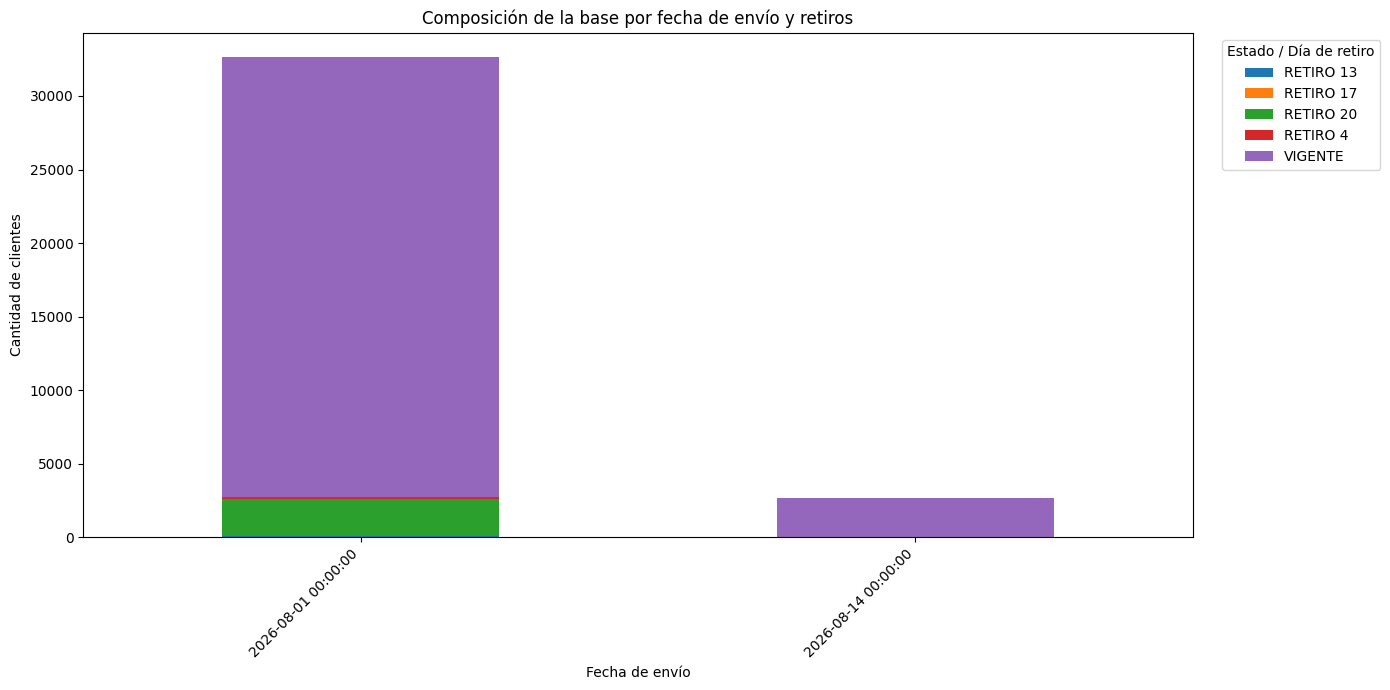

In [59]:
import matplotlib.pyplot as plt

ax = pivot_retiros.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

ax.set_title("Composición de la base por fecha de envío y retiros")
ax.set_xlabel("Fecha de envío")
ax.set_ylabel("Cantidad de clientes")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Estado / Día de retiro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [60]:
df_retiros = df_tc[
    df_tc["RETIRO"].notna()
].copy()

resumen_retiros = (
    df_retiros
    .groupby(
        ["FECHA_ENVIO", "dia_retiro"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

resumen_retiros

pivot_retiros = (
    resumen_retiros
    .pivot(
        index="FECHA_ENVIO",
        columns="dia_retiro",
        values="cantidad"
    )
    .fillna(0)
)

# Cambiar nombre de las columnas
pivot_retiros.columns = [
    f"RETIRO {int(col)}"
    for col in pivot_retiros.columns
]

pivot_retiros

,RETIRO 4,RETIRO 13,RETIRO 17,RETIRO 20
FECHA_ENVIO,,,,
2026-08-01,158.0,65.0,57.0,2496.0
2026-08-14,0.0,0.0,0.0,28.0


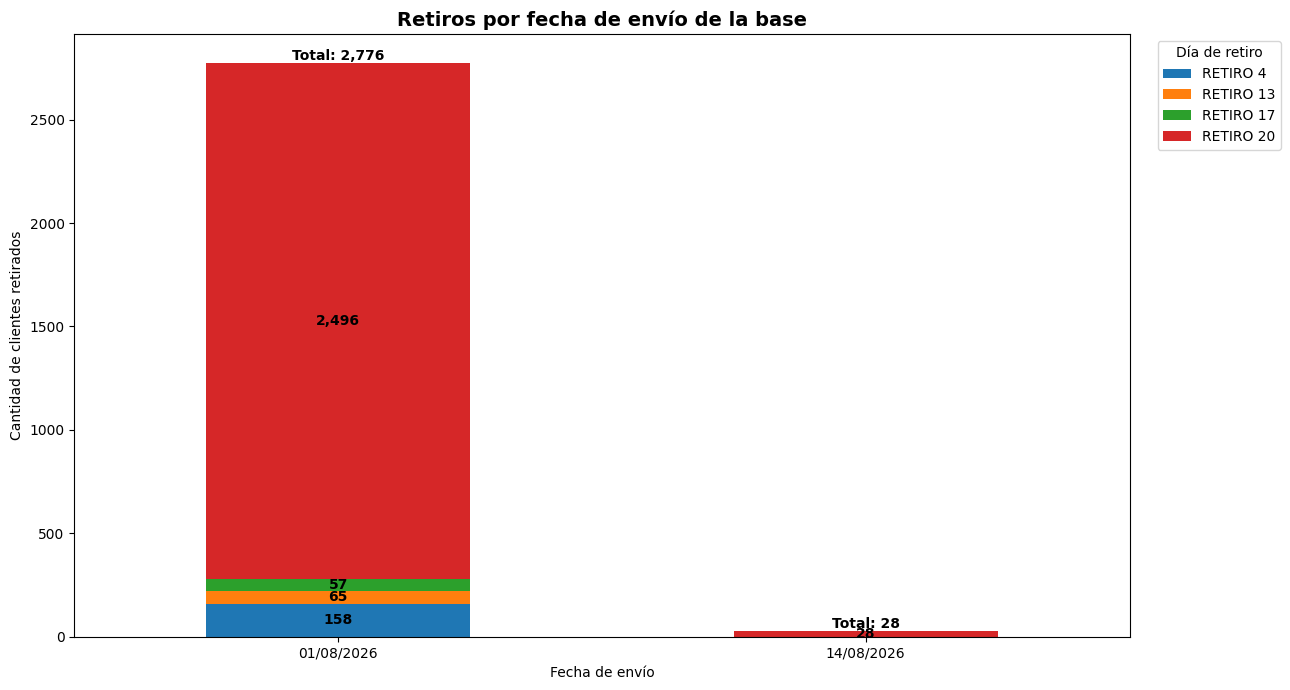

In [62]:
import matplotlib.pyplot as plt

ax = pivot_retiros.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

ax.set_title(
    "Retiros por fecha de envío de la base",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Fecha de envío")
ax.set_ylabel("Cantidad de clientes retirados")

# ============================================================
# ETIQUETAS DENTRO DE CADA SEGMENTO
# ============================================================

for container in ax.containers:
    
    labels = [
        f"{int(valor):,}" if valor > 0 else ""
        for valor in container.datavalues
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# TOTAL ENCIMA DE CADA BARRA
# ============================================================

totales = pivot_retiros.sum(axis=1)

for i, total in enumerate(totales):
    
    ax.text(
        i,
        total,
        f"Total: {int(total):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# FORMATO FECHAS
# ============================================================

ax.set_xticklabels(
    [
        fecha.strftime("%d/%m/%Y")
        if hasattr(fecha, "strftime")
        else str(fecha)
        for fecha in pivot_retiros.index
    ],
    rotation=0
)

plt.legend(
    title="Día de retiro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [63]:
pivot_retiros = (
    resumen_retiros
    .pivot(
        index="dia_retiro",      # Eje X
        columns="FECHA_ENVIO",   # Colores
        values="cantidad"
    )
    .fillna(0)
)

# Ordenar por día de retiro
pivot_retiros = pivot_retiros.sort_index()

pivot_retiros

FECHA_ENVIO,2026-08-01,2026-08-14
dia_retiro,,
4,158.0,0.0
13,65.0,0.0
17,57.0,0.0
20,2496.0,28.0


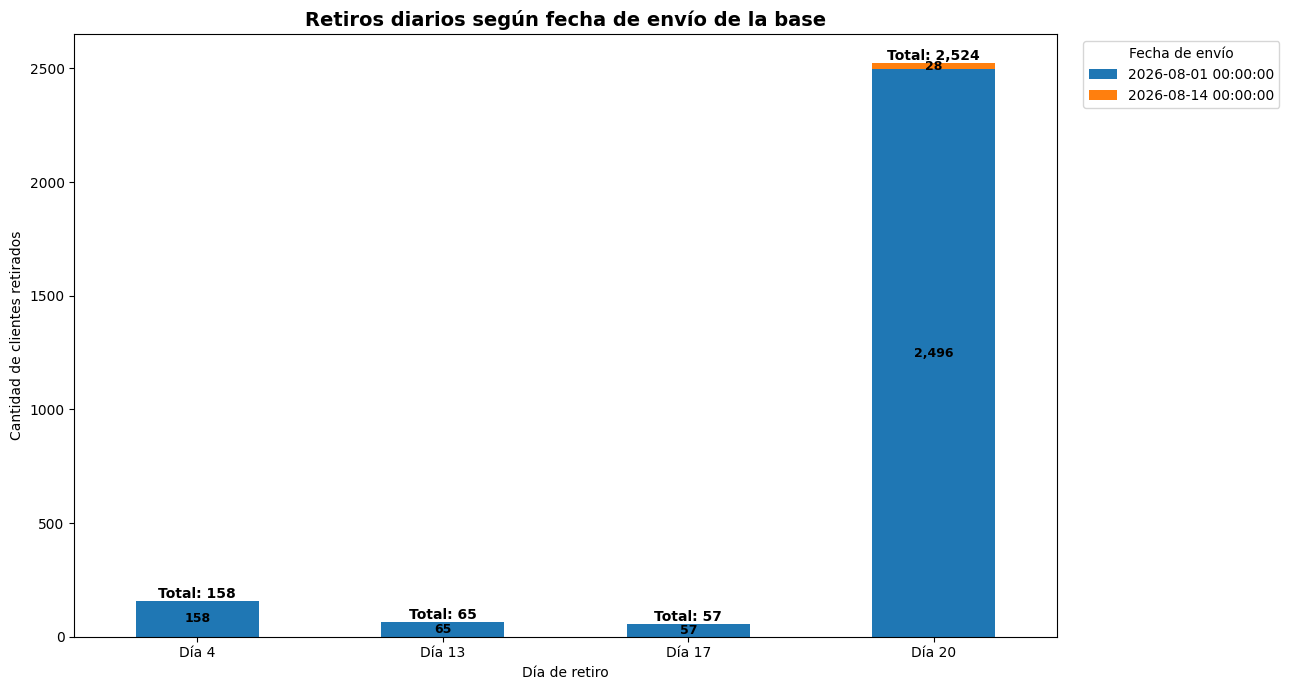

In [64]:
import matplotlib.pyplot as plt

ax = pivot_retiros.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

ax.set_title(
    "Retiros diarios según fecha de envío de la base",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Día de retiro")
ax.set_ylabel("Cantidad de clientes retirados")

# ============================================================
# ETIQUETAS DENTRO DE LAS BARRAS
# ============================================================

for container in ax.containers:
    
    labels = [
        f"{int(valor):,}" if valor > 0 else ""
        for valor in container.datavalues
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# TOTAL ENCIMA DE CADA DÍA
# ============================================================

totales = pivot_retiros.sum(axis=1)

for i, total in enumerate(totales):
    
    ax.text(
        i,
        total,
        f"Total: {int(total):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Día de retiro
ax.set_xticklabels(
    [f"Día {int(dia)}" for dia in pivot_retiros.index],
    rotation=0
)

# Leyenda = fecha en que recibimos la base
plt.legend(
    title="Fecha de envío",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

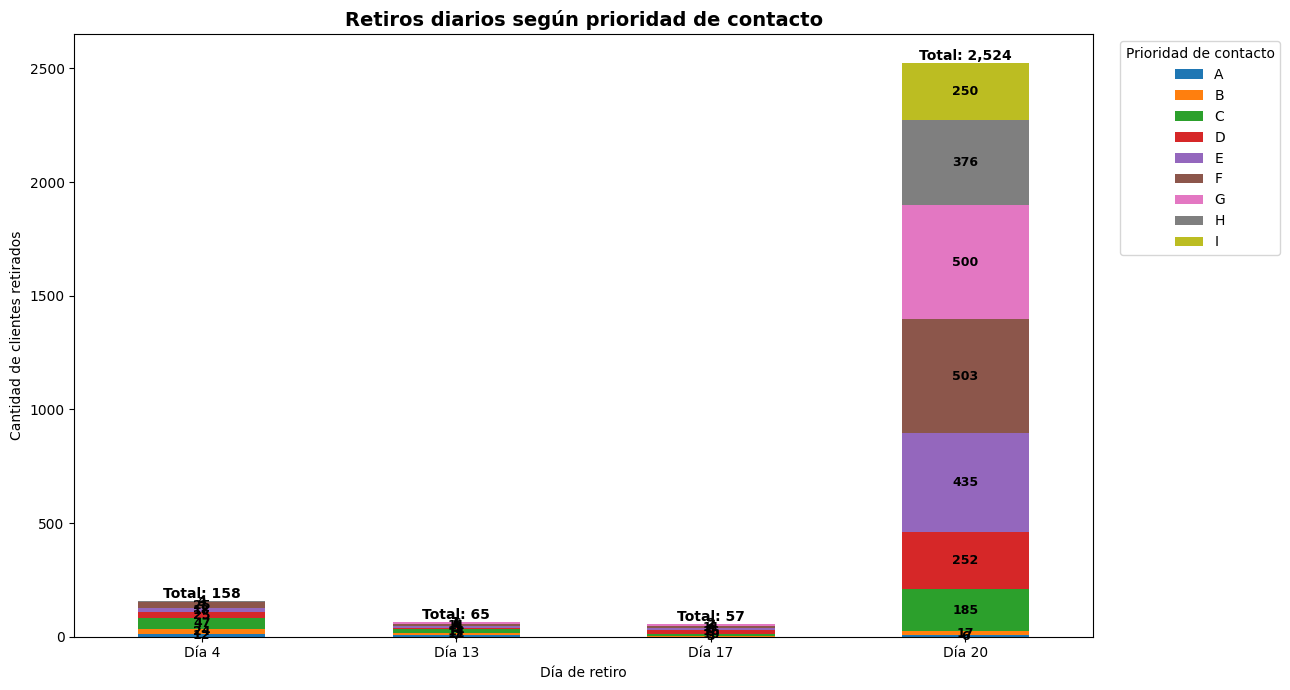

In [66]:
resumen_prob_retiro = (
    df_tc[df_tc["dia_retiro"].notna()]
    .groupby(
        ["dia_retiro", "PROB_CONTACTO"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

pivot_prob_retiro = (
    resumen_prob_retiro
    .pivot(
        index="dia_retiro",
        columns="PROB_CONTACTO",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

ax = pivot_prob_retiro.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7)
)

ax.set_title(
    "Retiros diarios según prioridad de contacto",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Día de retiro")
ax.set_ylabel("Cantidad de clientes retirados")

# ============================================================
# ETIQUETAS DENTRO DE CADA SEGMENTO
# ============================================================

for container in ax.containers:
    
    labels = [
        f"{int(valor):,}" if valor > 0 else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# TOTAL ENCIMA DE CADA BARRA
# ============================================================

totales = pivot_prob_retiro.sum(axis=1)

for i, total in enumerate(totales):

    ax.text(
        i,
        total,
        f"Total: {int(total):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# EJE X
# ============================================================

ax.set_xticklabels(
    [f"Día {int(dia)}" for dia in pivot_prob_retiro.index],
    rotation=0
)

plt.legend(
    title="Prioridad de contacto",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [67]:
pivot_prob_pct = (
    pivot_prob_retiro
    .div(pivot_prob_retiro.sum(axis=1), axis=0)
    .mul(100)
)

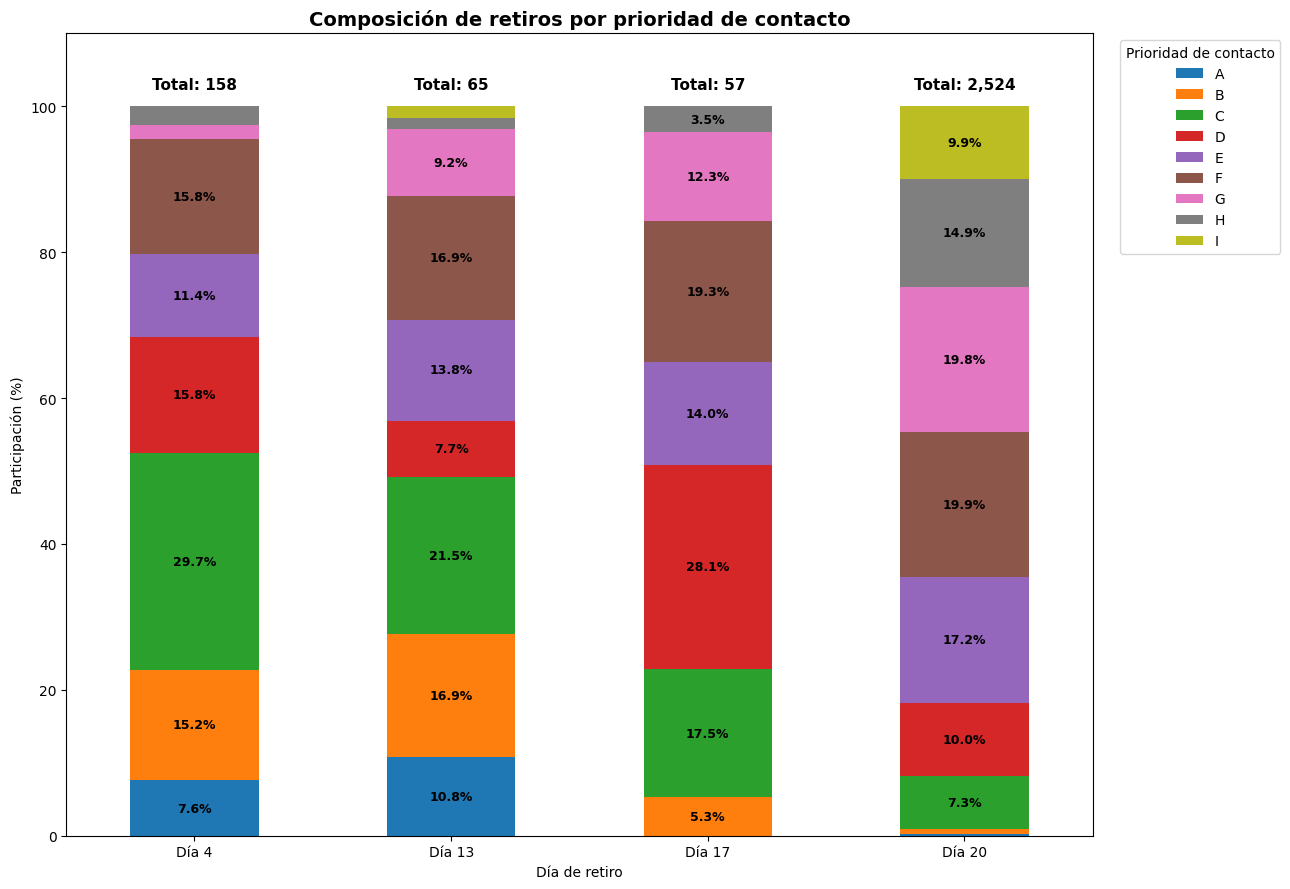

In [70]:
import matplotlib.pyplot as plt

# ============================================================
# 1. PORCENTAJE DE CADA PRIORIDAD POR DÍA
# ============================================================

pivot_prob_pct = (
    pivot_prob_retiro
    .div(pivot_prob_retiro.sum(axis=1), axis=0)
    .mul(100)
)

# ============================================================
# 2. TOTALES REALES POR DÍA
# ============================================================

totales = pivot_prob_retiro.sum(axis=1)

# ============================================================
# 3. GRÁFICO
# ============================================================

ax = pivot_prob_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 9)
)

ax.set_title(
    "Composición de retiros por prioridad de contacto",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Día de retiro")
ax.set_ylabel("Participación (%)")

# ============================================================
# 4. PORCENTAJES DENTRO DE CADA SEGMENTO
# ============================================================

for container in ax.containers:

    labels = [
        f"{valor:.1f}%" if valor >= 3 else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# 5. TOTAL REAL ENCIMA DE CADA BARRA
# ============================================================

for i, total in enumerate(totales):

    ax.text(
        i,
        102,
        f"Total: {int(total):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# 6. EJE X
# ============================================================

ax.set_xticklabels(
    [f"Día {int(dia)}" for dia in pivot_prob_pct.index],
    rotation=0
)

# Dejamos espacio arriba para los totales
ax.set_ylim(0, 110)

# ============================================================
# 7. LEYENDA
# ============================================================

plt.legend(
    title="Prioridad de contacto",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

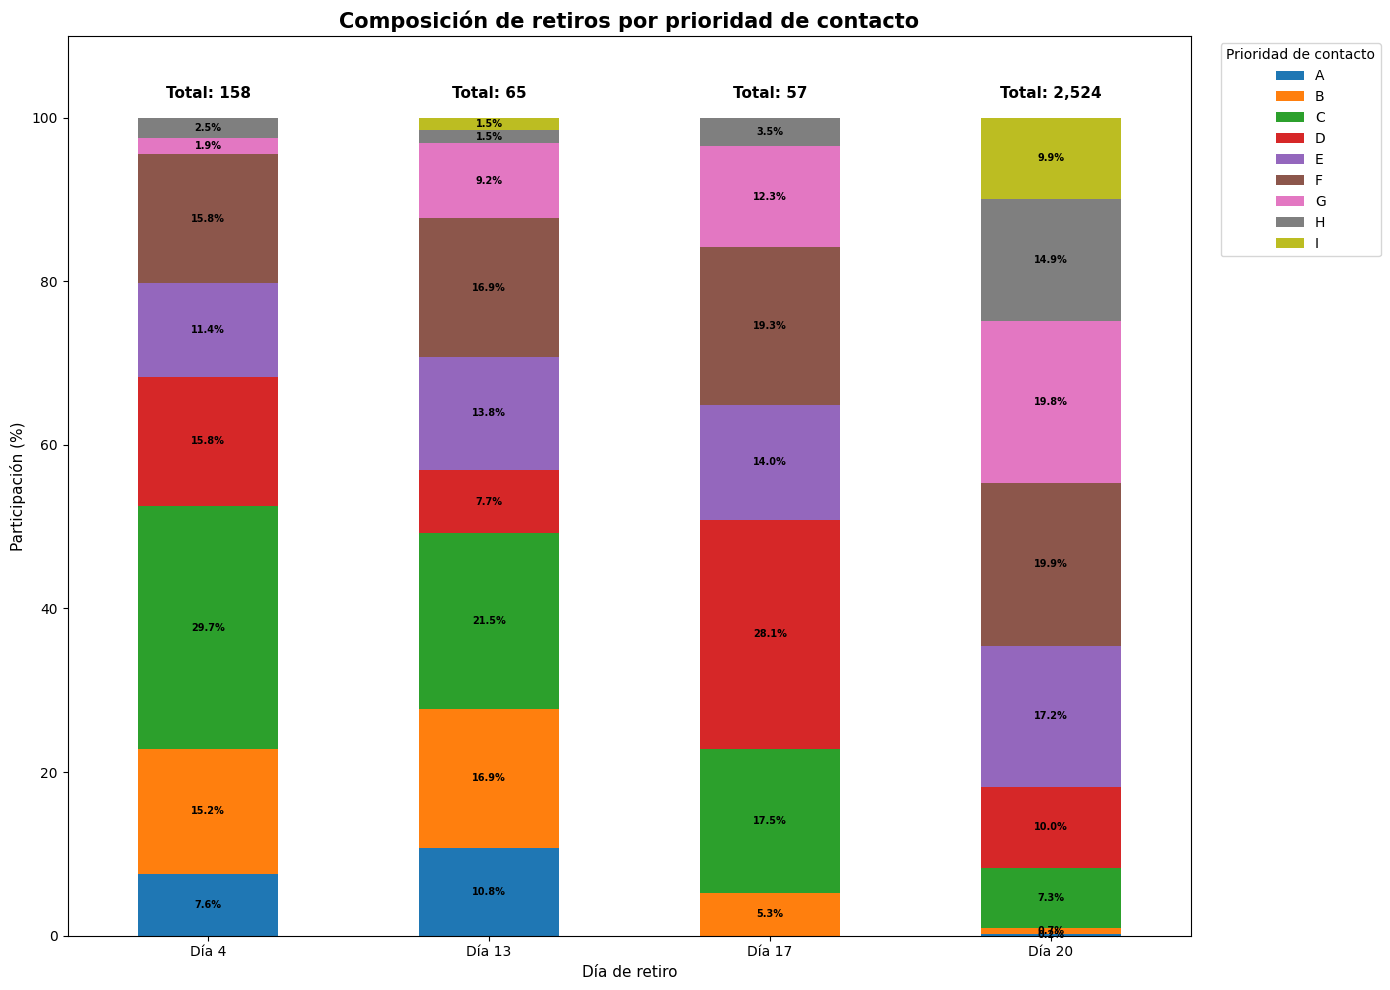

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. RESUMEN DE RETIROS POR DÍA Y PRIORIDAD
# ============================================================

resumen_prob_retiro = (
    df_tc[df_tc["dia_retiro"].notna()]
    .groupby(
        ["dia_retiro", "PROB_CONTACTO"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

# ============================================================
# 2. PIVOT CON CANTIDADES REALES
# ============================================================

pivot_prob_retiro = (
    resumen_prob_retiro
    .pivot(
        index="dia_retiro",
        columns="PROB_CONTACTO",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# ============================================================
# 3. CONVERTIR A PORCENTAJES
# CADA DÍA SUMA 100%
# ============================================================

pivot_prob_pct = (
    pivot_prob_retiro
    .div(
        pivot_prob_retiro.sum(axis=1),
        axis=0
    )
    .mul(100)
)

# ============================================================
# 4. TOTALES REALES POR DÍA
# ============================================================

totales = pivot_prob_retiro.sum(axis=1)

# ============================================================
# 5. GRÁFICO
# ============================================================

ax = pivot_prob_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 10)
)

# ============================================================
# 6. TÍTULO Y EJES
# ============================================================

ax.set_title(
    "Composición de retiros por prioridad de contacto",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Día de retiro",
    fontsize=11
)

ax.set_ylabel(
    "Participación (%)",
    fontsize=11
)

# ============================================================
# 7. PORCENTAJES DENTRO DE CADA SEGMENTO
# ============================================================

for container in ax.containers:

    labels = [
        f"{valor:.1f}%" if valor > 0 else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=7,
        fontweight="bold"
    )

# ============================================================
# 8. TOTAL REAL ENCIMA DE CADA BARRA
# ============================================================

for i, total in enumerate(totales):

    ax.text(
        i,
        102,
        f"Total: {int(total):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# 9. ETIQUETAS DEL EJE X
# ============================================================

ax.set_xticklabels(
    [
        f"Día {int(dia)}"
        for dia in pivot_prob_pct.index
    ],
    rotation=0
)

# ============================================================
# 10. DEJAR ESPACIO PARA LOS TOTALES
# ============================================================

ax.set_ylim(0, 110)

# ============================================================
# 11. LEYENDA
# ============================================================

plt.legend(
    title="Prioridad de contacto",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# ============================================================
# 12. AJUSTAR DISEÑO
# ============================================================

plt.tight_layout()

plt.show()

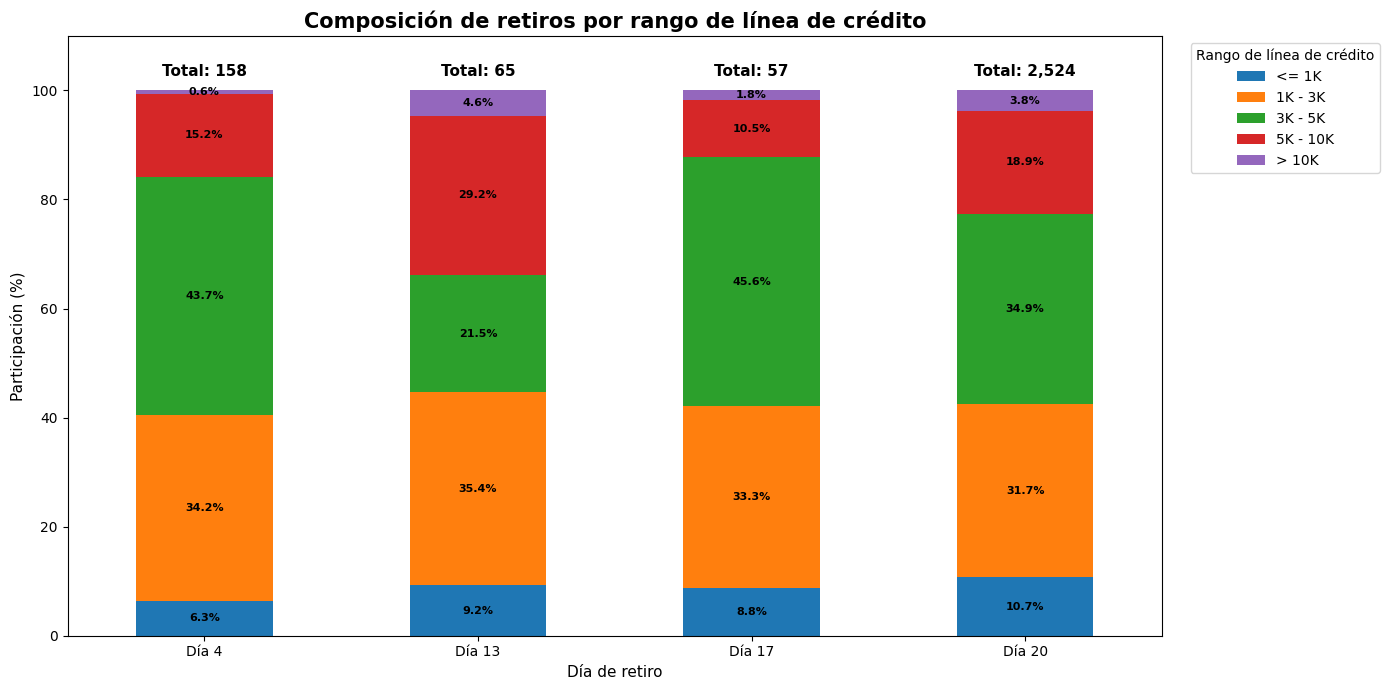

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. RESUMEN DE RETIROS POR DÍA Y RANGO DE LÍNEA
# ============================================================

resumen_linea_retiro = (
    df_tc[df_tc["dia_retiro"].notna()]
    .groupby(
        ["dia_retiro", "rango_linea"],
        observed=True,
        dropna=False
    )
    .size()
    .reset_index(name="cantidad")
)

# ============================================================
# 2. PIVOT CON CANTIDADES REALES
# ============================================================

pivot_linea_retiro = (
    resumen_linea_retiro
    .pivot(
        index="dia_retiro",
        columns="rango_linea",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# ============================================================
# 3. CONVERTIR A PORCENTAJES
# CADA DÍA DE RETIRO SUMA 100%
# ============================================================

pivot_linea_pct = (
    pivot_linea_retiro
    .div(
        pivot_linea_retiro.sum(axis=1),
        axis=0
    )
    .mul(100)
)

# ============================================================
# 4. TOTALES REALES POR DÍA
# ============================================================

totales = pivot_linea_retiro.sum(axis=1)

# ============================================================
# 5. GRÁFICO
# ============================================================

ax = pivot_linea_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

# ============================================================
# 6. TÍTULO Y EJES
# ============================================================

ax.set_title(
    "Composición de retiros por rango de línea de crédito",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Día de retiro",
    fontsize=11
)

ax.set_ylabel(
    "Participación (%)",
    fontsize=11
)

# ============================================================
# 7. PORCENTAJES DENTRO DE CADA SEGMENTO
# ============================================================

for container in ax.containers:

    labels = [
        f"{valor:.1f}%" if valor > 0 else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        fontweight="bold"
    )

# ============================================================
# 8. TOTAL REAL ENCIMA DE CADA BARRA
# ============================================================

for i, total in enumerate(totales):

    ax.text(
        i,
        102,
        f"Total: {int(total):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# 9. ETIQUETAS DEL EJE X
# ============================================================

ax.set_xticklabels(
    [
        f"Día {int(dia)}"
        for dia in pivot_linea_pct.index
    ],
    rotation=0
)

# ============================================================
# 10. ESPACIO PARA LOS TOTALES
# ============================================================

ax.set_ylim(0, 110)

# ============================================================
# 11. LEYENDA
# ============================================================

plt.legend(
    title="Rango de línea de crédito",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# ============================================================
# 12. AJUSTAR DISEÑO
# ============================================================

plt.tight_layout()

plt.show()

In [75]:
monto_retirado_dia = (
    df_tc[df_tc["dia_retiro"].notna()]
    .groupby("dia_retiro")
    .agg(
        clientes_retirados=("NUMERO_DOCUMENTO", "size"),
        linea_total_retirada=("LINEA CREDITO DOLARES", "sum"),
        linea_promedio=("LINEA CREDITO DOLARES", "mean")
    )
    .reset_index()
)

monto_retirado_dia["linea_promedio"] = (
    monto_retirado_dia["linea_promedio"].round(2)
)

monto_retirado_dia

,dia_retiro,clientes_retirados,linea_total_retirada,linea_promedio
0,4,158,573100,3627.22
1,13,65,283500,4361.54
2,17,57,193100,3387.72
3,20,2524,9747400,3861.89


## Embudo

In [76]:
import numpy as np
import pandas as pd

# Asegurar que sea numérica
df_tc["LINEA CREDITO DOLARES"] = pd.to_numeric(
    df_tc["LINEA CREDITO DOLARES"],
    errors="coerce"
)

df_tc["rango_oferta"] = pd.cut(
    df_tc["LINEA CREDITO DOLARES"],
    bins=[
        -np.inf,
        2000,
        4000,
        6000,
        8000,
        10000,
        12000,
        np.inf
    ],
    labels=[
        "B. < 2,000",
        "C. 2,000 A 4,000",
        "D. 4,000 A 6,000",
        "D. 6,000 A 8,000",
        "E. 8,000 A 10,000",
        "F. 10,000 A 12,000",
        "G. 12,000 A MÁS"
    ],
    include_lowest=True,
    right=False
)

In [77]:
import numpy as np
import pandas as pd

# ============================================================
# RETIRADO
# ============================================================

df_tc["es_retirado"] = df_tc["RETIRO"].notna()

# ============================================================
# PRIORIDAD COMERCIAL ALTA
# A-B-C-D
# ============================================================

df_tc["prioridad_alta"] = (
    df_tc["PROB_CONTACTO"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(["A", "B", "C", "D"])
)

total_base = len(df_tc)

total_retirados = (
    df_tc["es_retirado"]
    .sum()
)

retirados_prioridad_alta = (
    df_tc["es_retirado"]
    & df_tc["prioridad_alta"]
).sum()

In [79]:
pct_retirado = (
    total_retirados / total_base * 100
)

pct_alta_sobre_retirados = (
    retirados_prioridad_alta / total_retirados * 100
    if total_retirados > 0 else 0
)

pct_alta_sobre_base = (
    retirados_prioridad_alta / total_base * 100
)

In [80]:
print(f"Base total                     : {total_base:,}")
print(f"Total retirados                : {total_retirados:,}")
print(f"% retirado sobre base          : {pct_retirado:.2f}%")
print()
print(f"Retirados prioridad A-D        : {retirados_prioridad_alta:,}")
print(f"% A-D sobre retirados          : {pct_alta_sobre_retirados:.2f}%")
print(f"% A-D retirado sobre base      : {pct_alta_sobre_base:.2f}%")

Base total                     : 35,333
Total retirados                : 2,804
% retirado sobre base          : 7.94%

Retirados prioridad A-D        : 634
% A-D sobre retirados          : 22.61%
% A-D retirado sobre base      : 1.79%


In [81]:
embudo_retiro = pd.DataFrame({
    "etapa": [
        "Base total",
        "Base retirada",
        "Retirados prioridad A-D"
    ],
    "cantidad": [
        total_base,
        total_retirados,
        retirados_prioridad_alta
    ]
})

embudo_retiro["pct_base"] = (
    embudo_retiro["cantidad"]
    / total_base
    * 100
).round(2)

embudo_retiro

,etapa,cantidad,pct_base
0,Base total,35333,100.00
1,Base retirada,2804,7.94
2,Retirados prioridad A-D,634,1.79


In [82]:
import pandas as pd

desempeno_linea = pd.DataFrame({
    "rango_linea": [
        "B. 1,000 A 2,000",
        "C. 2,000 A 4,000",
        "D. 4,000 A 6,000",
        "D. 6,000 A 8,000",
        "E. 8,000 A 10,000",
        "F. 10,000 A 12,000",
        "G. 12,000 A MÁS"
    ],
    "leads": [
        7497,
        12213,
        7530,
        1720,
        2074,
        812,
        683
    ],
    "ventas": [
        31,
        64,
        55,
        18,
        10,
        2,
        3
    ]
})

desempeno_linea["tasa_venta"] = (
    desempeno_linea["ventas"]
    / desempeno_linea["leads"]
    * 100
)

# desempeno_linea

rangos_alto_desempeno = [
    "C. 2,000 A 4,000",
    "D. 4,000 A 6,000",
    "D. 6,000 A 8,000"
]

df_tc["rango_alto_desempeno"] = (
    df_tc["rango_linea"]
    .astype(str)
    .isin(rangos_alto_desempeno)
)


df_tc["prioridad_alta"] = (
    df_tc["PROB_CONTACTO"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(["A", "B", "C", "D"])
)


# ============================================================
# ETAPA 1 - BASE TOTAL
# ============================================================

total_base = len(df_tc)

# ============================================================
# ETAPA 2 - RETIRADOS
# ============================================================

total_retirados = (
    df_tc["RETIRO"].notna()
).sum()

# ============================================================
# ETAPA 3 - RETIRADOS A-D
# ============================================================

retirados_prioridad_alta = (
    df_tc["RETIRO"].notna()
    &
    df_tc["prioridad_alta"]
).sum()

# ============================================================
# ETAPA 4 - RETIRADOS A-D + RANGO DE ALTO DESEMPEÑO
# ============================================================

retirados_alto_valor = (
    df_tc["RETIRO"].notna()
    &
    df_tc["prioridad_alta"]
    &
    df_tc["rango_alto_desempeno"]
).sum()


embudo_retiro = pd.DataFrame({
    "etapa": [
        "Base total",
        "Base retirada",
        "Retirados prioridad A-D",
        "Retirados A-D + rango alto desempeño"
    ],
    "cantidad": [
        total_base,
        total_retirados,
        retirados_prioridad_alta,
        retirados_alto_valor
    ]
})

embudo_retiro["pct_sobre_base"] = (
    embudo_retiro["cantidad"]
    / total_base
    * 100
).round(2)


embudo_retiro["pct_vs_etapa_anterior"] = (
    embudo_retiro["cantidad"]
    / embudo_retiro["cantidad"].shift(1)
    * 100
).round(2)

embudo_retiro



,etapa,cantidad,pct_sobre_base,pct_vs_etapa_anterior
0,Base total,35333,100.00,NaN
1,Base retirada,2804,7.94,7.94
2,Retirados prioridad A-D,634,1.79,22.61
3,Retirados A-D + rango alto desempeño,0,0.00,0.00


In [83]:
embudo_retiro["pct_sobre_base_total"] = (
    embudo_retiro["cantidad"]
    / total_base
    * 100
).round(2)

embudo_retiro["pct_sobre_etapa_previa"] = (
    embudo_retiro["cantidad"]
    / embudo_retiro["cantidad"].shift(1)
    * 100
).round(2)

In [38]:
total_base = len(df_tc)

total_retirados = df_tc["RETIRO"].notna().sum()

total_vigentes = df_tc["RETIRO"].isna().sum()

pct_retirados = total_retirados / total_base * 100

print(f"Base inicial       : {total_base:,}")
print(f"Retirados          : {total_retirados:,}")
print(f"Base vigente       : {total_vigentes:,}")
print(f"% retirado         : {pct_retirados:.2f}%")

Base inicial       : 35,333
Retirados          : 2,804
Base vigente       : 32,529
% retirado         : 7.94%


In [25]:
print(df_tc.columns.tolist())

['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'CELULAR7', 'CELULAR8', 'CELULAR9', 'CELULAR10', 'PERFIL', 'PRODUCTO', 'LINEA CREDITO DOLARES', 'ID RESULTADO GESTION', 'TCEA', 'TCEA_CUOTAS_DF', 'LIMAPROVINCIA', 'GRUPO_EJECUCION', 'FEC_NAC', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'RECURRENCIA', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'CEL09', 'CEL10', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETI

In [ ]:
['ID PROVEEDOR', 'NOMBRES', 'APELLIDO PATERNO', 'APELLIDO MATERNO', 'TIPO DE DOCUMENTO', 'NUMERO_DOCUMENTO', 'TASA(TEA)', 'TEA_DF', 'TELEFONO_CASA1', 'TELEFONO_CASA2', 'TELEFONO_CASA3', 'TELEFONO_CASA4', 'TELEFONO_CASA5', 'TELEFONO_CASA6', 'TELEFONO_CASA7', 'TELEFONO_CASA8', 'TELEFONO_CASA9', 'TELEFONO_CASA10', 'CELULAR1', 'CELULAR2', 'CELULAR3', 'CELULAR4', 'CELULAR5', 'CELULAR6', 'CELULAR7', 'CELULAR8', 'CELULAR9', 'CELULAR10', 'PERFIL', 'PRODUCTO', 'LINEA CREDITO DOLARES', 'ID RESULTADO GESTION', 'TCEA', 'TCEA_CUOTAS_DF', 'LIMAPROVINCIA', 'GRUPO_EJECUCION', 'FEC_NAC', 'PROVINCIA', 'L_BCP', 'L_BBVA', 'L_IBK', 'L_SCO', 'L_BIF', 'L_CITI', 'L_FIN', 'L_RIP', 'L_CMR', 'L_CRESCO', 'L_CEN', 'L_AZT', 'L_UNO', 'L_GNB', 'L_EFE', 'L_COM', 'L_NAC', 'RECURRENCIA', 'CEL01', 'CEL02', 'CEL03', 'CEL04', 'CEL05', 'CEL06', 'CEL07', 'CEL08', 'CEL09', 'CEL10', 'TELF1', 'TELF2', 'TELF3', 'TELF4', 'TELF5', 'TELF6', 'TELF7', 'TELF8', 'FECHA_ENVIO', 'MES_DURACION_BASE', 'AÑO_DURACION_BASE', 'SERVICIO', 'RETIRO', 'MARCA', 'MARCA2', 'FLAT1', 'FLAT2', 'FLAT3', 'REP1', 'REP2', 'TASA_ANT', 'TCEA_ANT', 'FLG_BT', 'MONTO_OFERTA_BT', 'PRIORIDAD_TELEFONO_1', 'PRIORIDAD_TELEFONO_2', 'PRIORIDAD_TELEFONO_3', 'PRIORIDAD_TELEFONO_4', 'PRIORIDAD_TELEFONO_5', 'NEW_PROFILE', 'CPRUEBA', 'REP3', 'LAST_ENVIO', 'TASATEAA', 'TEA_DFA', 'TCEAA', 'TCEA_CUOTAS_DFA', 'MARCA3', 'PROP202407', 'PROP202407_el1ro5j', 'CAMPANASYD', 'DINERS_NRO1', 'DINERS_NRO2', 'DINERS_NRO3', 'DINERS_NRO4', 'DINERS_NRO5', 'OSIPTEL_NRO1_ENCRIP', 'OSIPTEL_NRO2_ENCRIP', 'OSIPTEL_NRO3_ENCRIP', 'PROB_CONTACTO', 'DCP01', 'DCP02', 'DCP03', 'DCP04', 'DCP05', 'CASHBACK', 'CONTEO', 'leadslanding', 'PROSPECTO_NUEVO', 'PROD_NOVIEMBRE', 'MEJ_PROD', 'LC', 'FLG_20241206', 'MAYOR_LINEA', 'MILLAS', 'prioridadtasas', 'prioridadedad', 'FRESCURA_TARGET', 'SEGMENTO_LABORAL', 'N_BASE', 'MARCA_SPEECH', 'BENCH_DINERS', 'FEC_ENV']RECU

In [ ]:
query = f"""
	select *
	from DANTALION.dbo.Base_Maestra_Diners_TC_Vigente
"""
df_tc = pd.read_sql(query, engine_kishin)




In [8]:
query = f"""
	select NUMERO_DOCUMENTO,PROB_CONTACTO,concat('2026-07-',right(retiro,2)) as retiro
	from DANTALION.dbo.Base_Maestra_Diners_TC_Vigente
    WHERE RETIRO IS not NULL OR RETIRO <>''
"""
df_tc = pd.read_sql(query, engine_kishin)

In [9]:
df_tc.head()

,NUMERO_DOCUMENTO,PROB_CONTACTO,retiro
0,47216152,D,2026-07-01
1,71561197,D,2026-07-01
2,42968074,C,2026-07-01
3,73473064,E,2026-07-01
4,46510882,C,2026-07-01


In [ ]:


server_sql = server_zeus
db_sql = "SAMANTHA"
user_sql = user_zeus
pwd_sql = pwd_zeus

engine_zeus = create_engine(
    f"mssql+pyodbc://{user_sql}:{pwd_sql}@{server_sql}/{db_sql}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
fecha_mes_base='2026-06-01'
campana=fecha_a_nombre('2026-05-01')
query = f"""
select dni as NumDoc, 1 as venta_target from SAMANTHA.dbo.Ventas_Target
where CAMPANA='Diners'
and CONVERT(DATE, FECHA) >= CONVERT(DATE, '{fecha_mes_base}')
AND CONVERT(DATE, FECHA) < DATEADD(MONTH, 1, CONVERT(DATE, '{fecha_mes_base}'))
   
"""
df_venta = pd.read_sql(query, engine_zeus)

df_target = df_tc.merge(
    df_venta,
    on='NumDoc',
    how='left'
)
df_final = df_target.merge(
    df,
    on='NumDoc',
    how='inner'
)
df_final = (
    df_final[df_final['venta_target'].isnull()]
    .drop(columns=['venta_target'])
)
df_final.rename(
    columns={
        'Importe Solicitado': 'Monto'
    },
    inplace=True
)
print(df_final.columns.tolist())

c:\Users\DATA\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


['NumDoc', 'TIPO_PRODUCTO', 'RETIRO', 'Canal', 'Autor', 'Subcanal', 'Motivo', 'Monto', 'fecha', 'hora']


In [72]:
df_final=df_final[df_final['Monto'].notnull()]

In [78]:
df_final[['TIPO_PRODUCTO','Canal', 'Monto', 'fecha']].head()


,TIPO_PRODUCTO,Canal,Monto,fecha
0,PPD,CANALES DIGITALES,41100.0,2026-06-04
1,PPD,CANALES DIGITALES,13800.0,2026-06-04
2,PPD,CONTACT CENTER,6000.0,2026-06-04


In [ ]:

total_monto_ppd = df_final.loc[
    df_final['TIPO_PRODUCTO'] == 'PPD',
    'Monto'
].sum()

total_ope_ppd = df_final.loc[
    df_final['TIPO_PRODUCTO'] == 'PPD',
    'Monto'
].count()

print(f'PPD | Monto total: {int(total_monto_ppd)} |  Total operaciones {int(total_ope_ppd)} ')

PPD | Monto total: 60900 |  Total operaciones 3 


In [ ]:
# ruta_archivo = os.path.join(ruta_csv, 'PPD_plus.xlsx')
# df_list_filtrada.to_excel(ruta_archivo, index=False)

In [ ]:
list_dni = (
    df_final.loc[df_final['RETIRO'].isna(), 'NumDoc']
    .dropna()
    .drop_duplicates()
    .tolist()
)

in_clause = ",".join(f"'{x}'" for x in list_dni)

try:
    with engine_kishin.begin() as conn:
        query = f"""
            UPDATE DANTALION.dbo.Base_Maestra_Diners
            SET RETIRO = 'RETIRO'
            WHERE NumDoc IN ({in_clause})
                and CONVERT(DATE, fecha_envio) >= CONVERT(DATE, '{fecha_mes_base}')
                AND CONVERT(DATE, fecha_envio) < DATEADD(MONTH, 1, CONVERT(DATE, '{fecha_mes_base}'))
        """
        result = conn.execute(text(query))
        print("Filas actualizadas:", result.rowcount)

except Exception as e:
    print(e)


In [77]:
exec_query_sql(server_kishin, db_kishin, user_kishin, pwd_kishin, "tNumeros_Diners", "SP tNumeros diners")
exec_query_sql(server_zeus, "ODIN", user_zeus, pwd_zeus, "EXEC Sp_Actualizar_Diners", "SP actualizar diners Zeus")
exec_query_sql(server_sa, "ODIN", user_sa, pwd_sa, "EXEC Sp_Actualizar_Diners", "SP actualizar diners SA")

SP tNumeros diners | realizado | duración: 5.48 seg
SP actualizar diners Zeus | realizado | duración: 5.54 seg
SP actualizar diners SA | realizado | duración: 1.5 seg


In [ ]:
resumen_fecha_envio = (
    df_tc
    .groupby("FECHA_ENVIO", dropna=False)
    .agg(
        base_enviada=("NUMERO_DOCUMENTO", "size"),
        retirados=("RETIRO", lambda x: x.notna().sum()),
        vigentes=("RETIRO", lambda x: x.isna().sum())
    )
    .reset_index()
)

resumen_fecha_envio["pct_retirado"] = (
    resumen_fecha_envio["retirados"]
    / resumen_fecha_envio["base_enviada"]
    * 100
).round(2)

resumen_fecha_envio